<a href="https://colab.research.google.com/github/tensorbytes0202/Transformer-v-s-Bert-from-scratch-/blob/main/BERT_vs_Transformer_(Scratch_Study).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE 1:


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from collections import Counter
from sklearn.model_selection import train_test_split

In [ ]:
train = pd.read_csv("/content/test.csv",
                    header=None,
                    names=["label","title","description"]
                    )
test = pd.read_csv(
    "test.csv",
    header=None,
    names=["label","title","description"]
)

print(train.shape)
print(test.shape)
train.head()

(7601, 3)
(7601, 3)


,label,title,description
0,Class Index,Title,Description
1,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
2,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
3,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
4,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...


In [ ]:
train["text"] = (
    train["title"].astype(str)
    + " "
    + train["description"].astype(str)
)

test["text"] = (
    test["title"].astype(str)
    + " "
    + test["description"].astype(str)
)

train = train[["text","label"]]
test = test[["text","label"]]

train.head()

,text,label
0,Title Description,Class Index
1,Fears for T N pension after talks Unions repre...,3
2,The Race is On: Second Private Team Sets Launc...,4
3,Ky. Company Wins Grant to Study Peptides (AP) ...,4
4,Prediction Unit Helps Forecast Wildfires (AP) ...,4


In [ ]:
train["length"]  =train["text"].apply(lambda x:len(str(x).split())
)

train["length"].describe()

,length
count,7601.000000
mean,37.716353
std,10.137051
min,2.000000
25%,32.000000
50%,37.000000
75%,43.000000
max,137.000000


In [ ]:
train["length"].quantile(0.95)

np.float64(52.0)

In [ ]:
import re

def tokenize(text):

    text = text.lower()

    text = re.sub(
        r'[^a-z0-9 ]',
        '',
        text
    )

    return text.split()

In [ ]:
tokenize(
    "Hello World! AI is Amazing."
)

['hello', 'world', 'ai', 'is', 'amazing']

In [ ]:
counter  = Counter()
for text in train["text"]:

  tokens = tokenize(text)
  counter.update(tokens)

word2idx = {
    "<PAD>":0,
    "<UNX":1
}

In [ ]:
idx = 2

for word,count in counter.items():
  if count >=2:
    word2idx[word] = idx

    idx+=1

In [ ]:
len(word2idx)

13670

In [ ]:
def encode(text):

  tokens = tokenize(text)

  return [
      word2idx.get(token,1)
      for token in tokens
  ]

In [ ]:
encode(
    "Artificial Intelligence"
)

[2935, 2458]

In [ ]:
MAX_LEN  = 100

def pad(sequence):
  sequence = sequence[:MAX_LEN]

  sequence += [0] * (
      MAX_LEN - len(sequence)
  )

  return sequence

In [ ]:
X = [
    pad(encode(text)
    )
    for text in train["text"]
]

y = train["label"].values

In [ ]:
print(len(X))
print(len(X[0]))

7601
100


In [ ]:
train["length"].describe()
train["length"].quantile(0.95)
len(word2idx)

13670

PHASE 2:


Hyper parameters

In [ ]:
VOCAB_SIZE = len(word2idx)

EMBED_DIM = 128
NUM_HEADS = 4

FF_DIM = 512

NUM_LAYERS = 2

NUM_CLASSES = 4
MAX_LEN = 100

DROUPOUT  = 0.1

Embedding Layer

In [ ]:
class TokenEmbedding(nn.Module):

  def __init__(self,vocab_size,embed_dim):

    super().__init__()

    self.embedding  = nn.Embedding(vocab_size,embed_dim,padding_idx=0)

  def forward(self,x):

    return self.embedding(x)

In [ ]:
emb = TokenEmbedding(
    VOCAB_SIZE,
    EMBED_DIM
)

sample = torch.tensor(X[:2])

print(
    emb(sample).shape
)

torch.Size([2, 100, 128])


In [ ]:
import math

Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):

  def __init__(self,embed_dim,max_len=5000):

    super().__init__()

    pe = torch.zeros(max_len,embed_dim)

    position = torch.arange(0,max_len).unsqueeze(1)

    div_term = torch.exp(torch.arange(0,embed_dim,2)*(-math.log(10000.0)/ embed_dim)
        )

    pe[:,0::2] = torch.sin(position * div_term)

    pe[:,1::2]  =torch.cos(position * div_term)

    pe = pe.unsqueeze(0)

    self.register_buffer("pe",pe)

  def forward(self,x):
       return x + self.pe[:,:x.size(1)]

In [ ]:
pos = PositionalEncoding(
    EMBED_DIM
)

out = pos(
    emb(sample)
)

print(out.shape)

torch.Size([2, 100, 128])


Multi-Head Attention


In [ ]:
class MultiHeadAttention(nn.Module):

  def __init__(
      self,
      embed_dim,
      num_heads
  ):

    super().__init__()

    self.embed_dim = embed_dim
    self.num_heads = num_heads
    self.head_dim = (embed_dim // num_heads)

    self.q_proj = nn.Linear(embed_dim,embed_dim)
    self.k_proj = nn.Linear(embed_dim,embed_dim)
    self.v_proj = nn.Linear(embed_dim,embed_dim)
    self.o_proj = nn.Linear(embed_dim,embed_dim)


  def forward(self,x):

    B,L,E  = x.shape

    Q = self.q_proj(x)
    k = self.k_proj(x)
    V = self.v_proj(x)

    Q = Q.view(B,L,self.num_heads,self.head_dim
          ).transpose(1,2)

    k = k.view(B,L,self.num_heads,self.head_dim
          ).transpose(1,2)

    V = V.view(B,L,self.num_heads,self.head_dim
          ).transpose(1,2)

    scores = torch.matmul(
        Q,
        k.transpose(-2,-1)
    )

    scores = scores / (
        self.head_dim ** 0.5
    )

    attention = torch.nn.functional.softmax(
        scores,
        dim = -1)

    out = torch.matmul(
        attention,
        V
    )

    out = out.transpose(1,2).contiguous()

    out = out.view(B,L,E)

    return self.o_proj(out)

In [ ]:
mha =  MultiHeadAttention(
    EMBED_DIM,
    NUM_HEADS
)

out = mha(out)

print(out.shape)


torch.Size([2, 100, 128])


Feed Forward Network

In [ ]:
class FeedForward(nn.Module):

  def __init__(self,embed_dim,ff_dim):

    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(embed_dim,ff_dim),

    nn.ReLU(),

    nn.Linear(
        ff_dim,
        embed_dim
    )
    )

  def forward(self,x):
    return self.net(x)

Encoder Block


In [ ]:
class EncoderBlock(nn.Module):

    def __init__(
        self,
        embed_dim,
        num_heads,
        ff_dim
    ):

        super().__init__()

        self.attn = MultiHeadAttention(
            embed_dim,
            num_heads
        )

        self.norm1 = nn.LayerNorm(
            embed_dim
        )

        self.ff = FeedForward(
            embed_dim,
            ff_dim
        )

        self.norm2 = nn.LayerNorm(
            embed_dim
        )

    def forward(self,x):

        x = self.norm1(
            x + self.attn(x)
        )

        x = self.norm2(
            x + self.ff(x)
        )

        return x

In [ ]:
encoder = EncoderBlock(
    EMBED_DIM,
    NUM_HEADS,
    FF_DIM
)

out = encoder(
    emb(sample)
)

print(out.shape)

torch.Size([2, 100, 128])


Phase 3

Transformer classifier


In [ ]:
class TransformerClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        ff_dim,
        num_layers,
        num_classes
    ):

        super().__init__()

        self.embedding = TokenEmbedding(
            vocab_size,
            embed_dim
        )

        self.positional = PositionalEncoding(
            embed_dim,
            MAX_LEN
        )

        self.encoders = nn.ModuleList(
            [
                EncoderBlock(
                    embed_dim,
                    num_heads,
                    ff_dim
                )
                for _ in range(num_layers)
            ]
        )

        self.dropout = nn.Dropout(0.1)

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(self,x):

        x = self.embedding(x)

        x = self.positional(x)

        for encoder in self.encoders:

            x = encoder(x)

        x = x.mean(dim=1)

        x = self.dropout(x)

        return self.classifier(x)

Create Model

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = TransformerClassifier(
    VOCAB_SIZE,
    EMBED_DIM,
    NUM_HEADS,
    FF_DIM,
    NUM_LAYERS,
    NUM_CLASSES
)

model = model.to(device)

print(model)

TransformerClassifier(
  (embedding): TokenEmbedding(
    (embedding): Embedding(13670, 128, padding_idx=0)
  )
  (positional): PositionalEncoding()
  (encoders): ModuleList(
    (0-1): 2 x EncoderBlock(
      (attn): MultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (o_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=128, bias=True)
        )
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=128, out_feature

Train/Validation Split

In [ ]:
# Clean the data and convert labels to 0-indexed (1-4 becomes 0-3)
mask = [str(label).isdigit() for label in y]
X_cleaned = [X[i] for i, valid in enumerate(mask) if valid]
y_cleaned = [int(y[i]) - 1 for i, valid in enumerate(mask) if valid]

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_cleaned,
    y_cleaned,
    test_size=0.2,
    random_state=42
)

Tensor Conversion

In [ ]:
X_train = torch.as_tensor(X_train, dtype=torch.long)
X_val = torch.as_tensor(X_val, dtype=torch.long)
y_train = torch.as_tensor(y_train, dtype=torch.long)
y_val = torch.as_tensor(y_val, dtype=torch.long)

DataLoader

In [ ]:
from torch.utils.data import (
    TensorDataset,
    DataLoader
)

train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

Training Function

In [ ]:
def train_epoch():

    model.train()

    total_loss = 0

    correct = 0

    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == y_batch
        ).sum().item()

        total += y_batch.size(0)

    return (
        total_loss / len(train_loader),
        correct / total
    )

In [ ]:
def evaluate():

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for X_batch,y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            preds = outputs.argmax(1)

            correct += (
                preds == y_batch
            ).sum().item()

            total += y_batch.size(0)

    return correct / total

In [ ]:
EPOCHS = 10

In [ ]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch()

    val_acc = evaluate()

    print(
        f"Epoch {epoch+1}"
        f" | Loss={train_loss:.4f}"
        f" | Train Acc={train_acc:.4f}"
        f" | Val Acc={val_acc:.4f}"
    )

Epoch 1 | Loss=1.3905 | Train Acc=0.2681 | Val Acc=0.2954
Epoch 2 | Loss=1.3421 | Train Acc=0.3632 | Val Acc=0.4033
Epoch 3 | Loss=1.1867 | Train Acc=0.4834 | Val Acc=0.5651
Epoch 4 | Loss=0.9326 | Train Acc=0.6289 | Val Acc=0.6309
Epoch 5 | Loss=0.7311 | Train Acc=0.7209 | Val Acc=0.7020
Epoch 6 | Loss=0.6121 | Train Acc=0.7742 | Val Acc=0.7289
Epoch 7 | Loss=0.5289 | Train Acc=0.8084 | Val Acc=0.7349
Epoch 8 | Loss=0.4631 | Train Acc=0.8395 | Val Acc=0.7480
Epoch 9 | Loss=0.4198 | Train Acc=0.8538 | Val Acc=0.7618
Epoch 10 | Loss=0.3726 | Train Acc=0.8753 | Val Acc=0.7592


Phase 4



In [ ]:
# The 'text' column already exists from previous cells.
# We just need to clean and encode it.
mask_test = [str(label).isdigit() for label in test["label"]]

X_test_cleaned = [test["text"].iloc[i] for i, valid in enumerate(mask_test) if valid]
y_test_cleaned = [int(test["label"].iloc[i]) - 1 for i, valid in enumerate(mask_test) if valid]

X_test = torch.as_tensor(
    [pad(encode(text)) for text in X_test_cleaned],
    dtype=torch.long
)

y_test = torch.as_tensor(
    y_test_cleaned,
    dtype=torch.long
)

In [ ]:
X_test = torch.tensor(
    X_test,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

/tmp/ipykernel_2058/1877007500.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(
/tmp/ipykernel_2058/1877007500.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(


In [ ]:
test_dataset = TensorDataset(X_test,y_test)

test_loader  = DataLoader(test_dataset,
                          batch_size=64)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        preds = outputs.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            y_batch.numpy()
        )

In [ ]:
acc = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.865
Precision: 0.8680252204639776
Recall   : 0.865
F1 Score : 0.8642888574637553


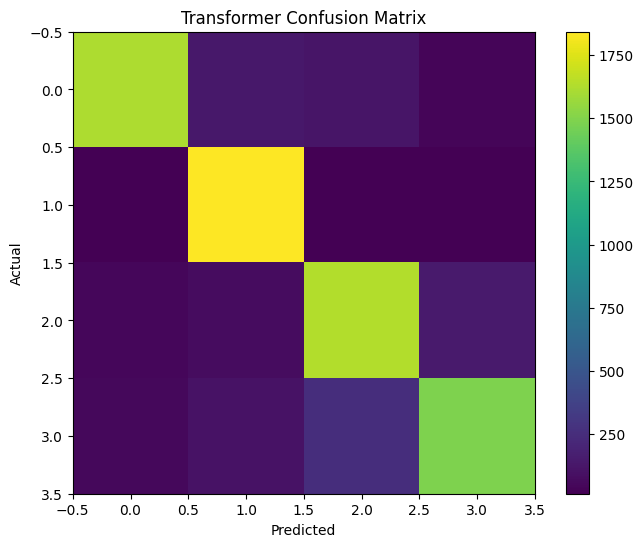

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.title(
    "Transformer Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)
print(
    f"Parameters: {total_params:,}"
)

Parameters: 2,146,820


In [ ]:
torch.save(
    model.state_dict(),
    "transformer_baseline.pth"
)

MINI-BERT Model

Phase 5

In [ ]:
BERT_EMBED_DIM = 128

BERT_HEADS = 4

BERT_FF_DIM = 512

BERT_LAYERS =2

MAX_LEN =100

BERT Embeddings

Token Embedding
+
Position Embedding
+
Segment Embedding

In [ ]:
class BERTEmbeddings(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        max_len
    ):

        super().__init__()

        self.token_embed = nn.Embedding(
            vocab_size,
            embed_dim
        )

        self.position_embed = nn.Embedding(
            max_len,
            embed_dim
        )

        self.segment_embed = nn.Embedding(
            2,
            embed_dim
        )

    def forward(
        self,
        input_ids,
        segment_ids
    ):

        seq_len = input_ids.size(1)

        positions = torch.arange(
            seq_len,
            device=input_ids.device
        ).unsqueeze(0)

        token_embeddings = self.token_embed(
            input_ids
        )

        position_embeddings = self.position_embed(
            positions
        )

        segment_embeddings = self.segment_embed(
            segment_ids
        )

        return (
            token_embeddings
            + position_embeddings
            + segment_embeddings
        )

MLM Head

In [ ]:
class MLMHead(nn.Module):

    def __init__(
        self,
        embed_dim,
        vocab_size
    ):

        super().__init__()

        self.linear = nn.Linear(
            embed_dim,
            vocab_size
        )

    def forward(self,x):

        return self.linear(x)

In [ ]:
class NSPHead(nn.Module):

    def __init__(
        self,
        embed_dim
    ):

        super().__init__()

        self.linear = nn.Linear(
            embed_dim,
            2
        )

    def forward(self,x):

        return self.linear(x)

Mini-BERT Model

In [ ]:
class MiniBERT(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        ff_dim,
        num_layers,
        max_len
    ):

        super().__init__()

        self.embeddings = BERTEmbeddings(
            vocab_size,
            embed_dim,
            max_len
        )

        self.encoders = nn.ModuleList(
            [
                EncoderBlock(
                    embed_dim,
                    num_heads,
                    ff_dim
                )
                for _ in range(num_layers)
            ]
        )

        self.mlm_head = MLMHead(
            embed_dim,
            vocab_size
        )

        self.nsp_head = NSPHead(
            embed_dim
        )

    def forward(
        self,
        input_ids,
        segment_ids
    ):

        x = self.embeddings(
            input_ids,
            segment_ids
        )

        for encoder in self.encoders:

            x = encoder(x)

        mlm_logits = self.mlm_head(
            x
        )

        cls_token = x[:,0]

        nsp_logits = self.nsp_head(
            cls_token
        )

        return (
            mlm_logits,
            nsp_logits
        )

Create Model

In [ ]:
bert = MiniBERT(
    VOCAB_SIZE,
    BERT_EMBED_DIM,
    BERT_HEADS,
    BERT_FF_DIM,
    BERT_LAYERS,
    MAX_LEN
)

bert = bert.to(device)

Add Special Tokens

In [ ]:
word2idx["[PAD]"] = len(word2idx)
word2idx["[CLS]"] = len(word2idx)
word2idx["[SEP]"] = len(word2idx)
word2idx["[MASK]"] = len(word2idx)

In [ ]:
import random

def mask_tokens(tokens):

    labels = []

    output = []

    for token in tokens:

        if random.random() < 0.15:

            labels.append(token)

            output.append(
                word2idx["[MASK]"]
            )

        else:

            labels.append(-100)

            output.append(token)

    return output, labels

Add Classification Head

In [ ]:
class BERTClassifier(nn.Module):

    def __init__(
        self,
        bert_model,
        embed_dim,
        num_classes
    ):

        super().__init__()

        self.embeddings = bert_model.embeddings

        self.encoders = bert_model.encoders

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(
        self,
        input_ids,
        segment_ids
    ):

        x = self.embeddings(
            input_ids,
            segment_ids
        )

        for encoder in self.encoders:

            x = encoder(x)

        cls_token = x[:,0]

        return self.classifier(
            cls_token
        )

MLM Loss

In [ ]:
mlm_loss_fn = nn.CrossEntropyLoss(
    ignore_index=-100
)

NSP Loss

In [ ]:
nsp_loss_fn = nn.CrossEntropyLoss()



Optimizer

In [ ]:
optimizer = torch.optim.Adam(
    bert.parameters(),
    lr=1e-4
)

Pretraining Loop

In [ ]:
def pretrain_epoch():

    bert.train()

    total_loss = 0

    for (
        input_ids,
        segment_ids,
        mlm_labels,
        nsp_labels
    ) in pretrain_loader:

        input_ids = input_ids.to(device)

        segment_ids = segment_ids.to(device)

        mlm_labels = mlm_labels.to(device)

        nsp_labels = nsp_labels.to(device)

        optimizer.zero_grad()

        mlm_logits,nsp_logits = bert(
            input_ids,
            segment_ids
        )

        mlm_loss = mlm_loss_fn(
            mlm_logits.view(
                -1,
                VOCAB_SIZE
            ),
            mlm_labels.view(-1)
        )

        nsp_loss = nsp_loss_fn(
            nsp_logits,
            nsp_labels
        )

        loss = (
            mlm_loss
            +
            nsp_loss
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss

Pretrain

In [ ]:
PRETRAIN_EPOCHS = 10

In [ ]:
for epoch in range(
    PRETRAIN_EPOCHS
):

    loss = pretrain_epoch()

    print(
        f"Epoch {epoch+1}"
        f" Loss={loss:.4f}"
    )

Save Pretrained BERT

In [ ]:
torch.save(
    bert.state_dict(),
    "mini_bert_pretrained.pth"
)

Build Classification Model

In [ ]:
bert_classifier = BERTClassifier(
    bert,
    BERT_EMBED_DIM,
    4
)

bert_classifier = bert_classifier.to(
    device
)

Segment IDs

In [ ]:
segment_ids = torch.zeros_like(
    X_train
)

Fine-Tuning Loss

In [ ]:
criterion = nn.CrossEntropyLoss()

Fine-Tuning Optimizer

In [ ]:
optimizer = torch.optim.Adam(
    bert_classifier.parameters(),
    lr = 2e-5
)

Fine-Tuning Train Loop

In [ ]:
def train_bert_epoch():

    bert_classifier.train()

    total_loss = 0

    correct = 0

    total = 0

    for (
        X_batch,
        y_batch
    ) in train_loader:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        segment_batch = torch.zeros_like(
            X_batch
        )

        optimizer.zero_grad()

        outputs = bert_classifier(
            X_batch,
            segment_batch
        )

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == y_batch
        ).sum().item()

        total += y_batch.size(0)

    return (
        total_loss / len(train_loader),
        correct / total
    )

In [ ]:
segment_batch = torch.zeros_like(
    X_batch
)